In [7]:
import numpy as np
import os
import mat73
import seaborn as sb
import pingouin as pg
import PcmPy as pcm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import ttest_1samp
import pandas as pd
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from SensoriMotorPrediction.vis import plot_rdm, plot_surf
import SensoriMotorPrediction.globals as gl

In [8]:
experiment = 'smp2'
H = 'R'
epoch = 'plan'
rois = gl.rois['ROI']
glm = 12

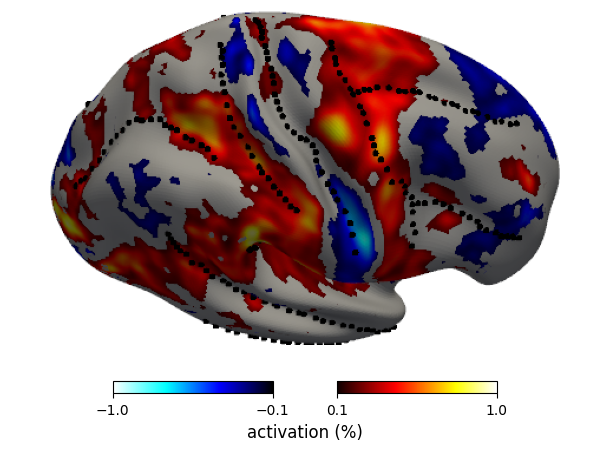

In [9]:
cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'
thresh = .1
vmin, vmax = -1, 1

cifti = nb.load(os.path.join('data', 'activation', 'activation_map_glm_main.dscalar.nii'))
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (%)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

fig.savefig(os.path.join('figures', 'surface.activation.plan.R.pdf'))

plt.show()

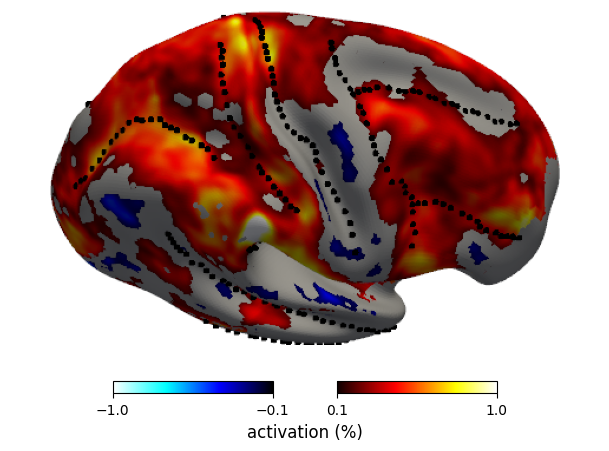

In [10]:
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)

cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (%)', y=.001)

cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

fig.savefig(os.path.join('figures', 'surface.activation.exec.R.pdf'))

plt.show()

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.396, pval=0.002
PMd: tval=5.916, pval=0.000
PMv: tval=3.119, pval=0.004
M1: tval=4.753, pval=0.000
S1: tval=2.659, pval=0.010
SPLa: tval=5.338, pval=0.000
SPLp: tval=5.531, pval=0.000


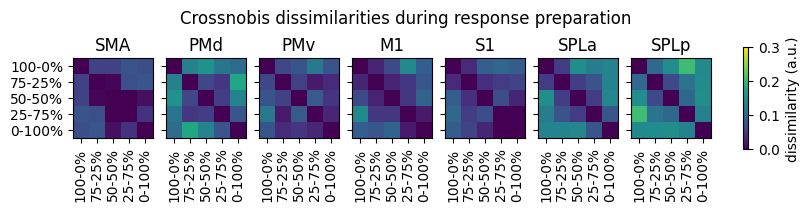

In [11]:
vmin, vmax = 0, .3

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response preparation')
fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.R.pdf'))
plt.show()

                                T  dof     p-val         CI95%
roi  component                                                
M1   expectation T-test  1.660187   13  0.060396  [-0.33, inf]
     uncertainty T-test  0.961559   13  0.176908  [-0.43, inf]
PMd  expectation T-test  2.837236   13  0.006998   [0.99, inf]
     uncertainty T-test  2.967226   13  0.005452   [2.59, inf]
PMv  expectation T-test  1.483700   13  0.080862  [-0.22, inf]
     uncertainty T-test  0.871210   13  0.199722  [-0.93, inf]
S1   expectation T-test  2.043278   13  0.030921    [0.6, inf]
     uncertainty T-test  0.845454   13  0.206574   [-1.0, inf]
SMA  expectation T-test  0.428867   13  0.337521  [-0.63, inf]
     uncertainty T-test  0.426056   13  0.338518  [-1.04, inf]
SPLa expectation T-test  3.009468   13  0.005027   [1.35, inf]
     uncertainty T-test  1.788823   13  0.048479   [0.03, inf]
SPLp expectation T-test  2.600470   13  0.010993   [1.85, inf]
     uncertainty T-test  2.861382   13  0.006681    [3.

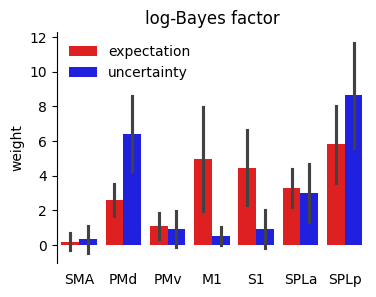

In [12]:
comp_model_human = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
comp_model_human = comp_model_human[(comp_model_human.epoch=='plan') & (comp_model_human.Hem==H) & (comp_model_human.glm==glm) & (comp_model_human.method=='raw')]
sep = [.5, 1.5, 2.5, 3.5, 4.5, 5.5]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=comp_model_human, x='roi', y='BF', hue='component', palette=['red', 'blue'], errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor')
ttest = comp_model_human.groupby(['roi', 'component'])['BF'].apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(ttest[['T', 'dof', 'p-val', 'CI95%']])
plt.show()

               T   dof     p-unc
roi                             
M1   0  1.023663  13.0  0.162333
PMd  0 -1.507568  13.0  0.922212
PMv  0  0.742821  13.0  0.235400
S1   0  1.866574  13.0  0.042338
SMA  0  0.191844  13.0  0.425414
SPLa 0  0.350439  13.0  0.365811
SPLp 0 -0.530064  13.0  0.697498


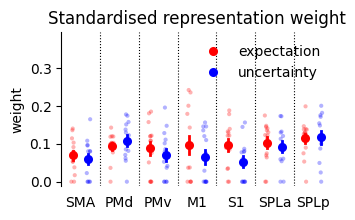

In [22]:
fig, ax = plt.subplots(figsize=(3.5, 2))
comp_model_human['norm_weight'] = np.sqrt(comp_model_human['weight'] / comp_model_human['noise'])
sb.pointplot(ax=ax, data=comp_model_human, x='roi', y='norm_weight', hue='component', palette=['red', 'blue'], errorbar='se', dodge=.4, ls='none', lw=2)
sb.stripplot(ax=ax, data=comp_model_human, x='roi', y='norm_weight', hue='component', palette=['red', 'blue'], size=3, alpha=.3, jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_ylim([None, .395])
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest = comp_model_human.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='greater'))
print(ttest[['T', 'dof', 'p-unc',]])
fig.savefig(os.path.join('figures', f'weight.plan.glm{glm}.R.pdf'))
plt.show()

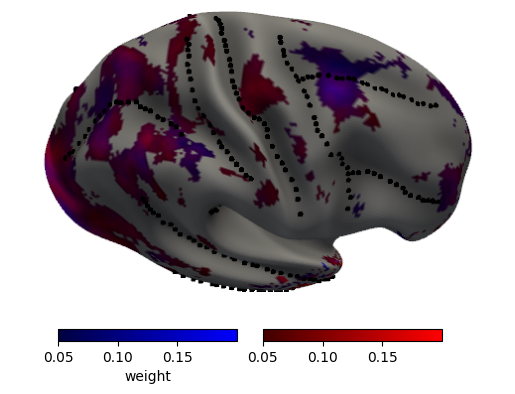

In [14]:
vmin = .05
vmax = .20

gifti = nb.load(os.path.join(gl.baseDir, 'smp2', gl.surfDir, f'searchlight.component_model.glm{glm}.plan.{H}.func.gii')) #f'searchlight.var_expl.plan.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
data = data[:, :2] #/ data[:, -1][:, None]
raw_max = np.nanmax(data)
data_s = data / raw_max
mclip = vmax / raw_max
threshold = vmin / vmax
data_c = np.clip(data_s / mclip , 0, 1) #

sulc = nt.get_gifti_data_matrix(nb.load(os.path.join('atlases', 'fs_LR.32k.LR.sulc.dscalar.gii')))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

overlay_mask = (data_c[:, 0] >= threshold) | (data_c[:, 1] >= threshold)

rgba[overlay_mask, 0] = data_c[overlay_mask, 0]  # red
rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
rgba[overlay_mask, 2] = data_c[overlay_mask, 1]  # blue
rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
rgba[~overlay_mask, 3] = 1.0                    # still show grey background

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb', thresh=None)

blue_half = LinearSegmentedColormap.from_list("blue_half", [(0, 0, threshold), (0, 0, 1)])
neg_norm = Normalize(vmin=threshold * mclip * raw_max, vmax=raw_max * mclip)
sm_neg = ScalarMappable(norm=neg_norm, cmap=blue_half)

red_half = LinearSegmentedColormap.from_list("red_half", [(threshold, 0, 0), (1, 0, 0)])
pos_norm = Normalize(vmin=threshold * mclip * raw_max, vmax=raw_max * mclip)
sm_pos = ScalarMappable(norm=pos_norm, cmap=red_half)

cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left (blue)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (red)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('weight')

fig.savefig(os.path.join('figures', f'surface.weight.plan.{H}.pdf'))

plt.show()

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=6.603, pval=0.000
PMd: tval=4.902, pval=0.000
PMv: tval=3.899, pval=0.001
M1: tval=4.887, pval=0.000
S1: tval=4.371, pval=0.000
SPLa: tval=3.844, pval=0.001
SPLp: tval=9.826, pval=0.000


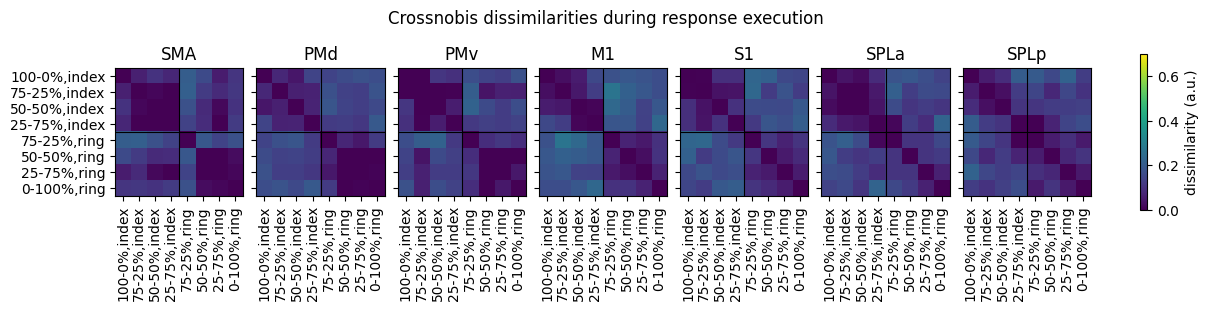

In [15]:
vmin, vmax = 0, .7

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    plot_rdm(fig, axs, r, D, gl.conditions[5:], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].axhline(3.5, color='k', lw=.8)
    axs[r].axvline(3.5, color='k', lw=.8)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')
fig.savefig(os.path.join('figures', 'crossnobis.exec.R.pdf'))
plt.show()

                                       T  dof     p-val
roi  component                                         
M1   expectation   T-test      -2.020712   13  0.967798
     sensory input T-test       1.910436   13  0.039192
     surprise      T-test       3.374902   13  0.002488
PMd  expectation   T-test     -14.385985   13  1.000000
     sensory input T-test       1.483381   13  0.080904
     surprise      T-test       4.672288   13  0.000218
PMv  expectation   T-test -470345.604680   13  1.000000
     sensory input T-test       1.149842   13  0.135462
     surprise      T-test       3.530478   13  0.001846
S1   expectation   T-test      -7.424233   13  0.999997
     sensory input T-test       1.588955   13  0.068043
     surprise      T-test       3.230900   13  0.003283
SMA  expectation   T-test     -17.804074   13  1.000000
     sensory input T-test      -0.699267   13  0.751646
     surprise      T-test       3.273693   13  0.003023
SPLa expectation   T-test -276606.244075   13  1

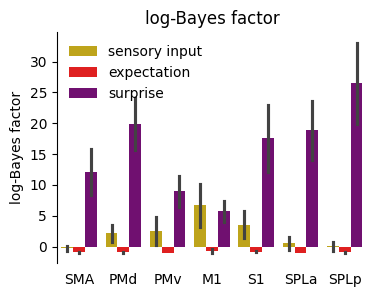

In [16]:
df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
df = df[(df.epoch=='exec') & (df.Hem==H) & (df.glm==glm)]
sep = [.5, 1.5, 2.5, 3.5, 4.5, 5.5]
fig, ax = plt.subplots(figsize=(4, 3))
palette = ['#D9B700', 'red', 'purple']
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette = palette, errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('log-Bayes factor')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor')
ttest = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(ttest[['T', 'dof', 'p-val']])
plt.show()

                    A              B         T   dof alternative     p-unc
roi                                                                       
M1   0    expectation  sensory input -3.477255  13.0        less  0.002044
     1    expectation       surprise -5.563150  13.0        less  0.000046
     2  sensory input       surprise -0.335189  13.0        less  0.371415
PMd  0    expectation  sensory input -1.899898  13.0        less  0.039928
     1    expectation       surprise -6.818792  13.0        less  0.000006
     2  sensory input       surprise -5.237771  13.0        less  0.000080
PMv  0    expectation  sensory input -2.790135  13.0        less  0.007658
     1    expectation       surprise -7.451298  13.0        less  0.000002
     2  sensory input       surprise -2.667070  13.0        less  0.009686
S1   0    expectation  sensory input -2.117576  13.0        less  0.027029
     1    expectation       surprise -6.425868  13.0        less  0.000011
     2  sensory input    

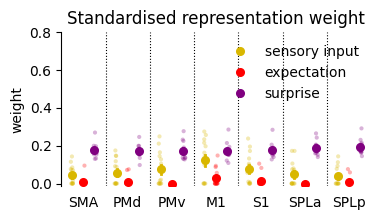

In [25]:
fig, ax = plt.subplots(figsize=(4, 2))
df['norm_weight'] = np.sqrt(df['weight']/ df['noise'])
sb.pointplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', palette = palette, errorbar='se', estimator='mean', lw=2, ls='none', dodge=.5)
sb.stripplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', size=3, alpha=.3, palette = palette, jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_ylim((None, .8))
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
for s in sep:
    ax.axvline(s, lw=.8, ls=':', color='k')
ttest_dep = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='less'))
print(ttest_dep[['A', 'B', 'T', 'dof', 'alternative', 'p-unc']])
fig.savefig(os.path.join('figures', 'weight.exec.R.pdf'))
plt.show()

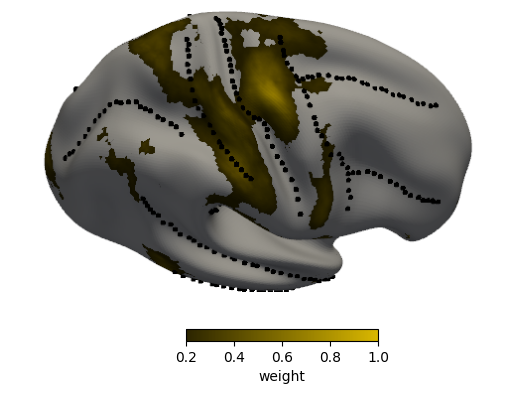

In [18]:
gifti = nb.load(os.path.join(gl.baseDir, 'smp2', gl.surfDir, f'searchlight.component_model.glm{glm}.exec.R.func.gii'))
data = nt.get_gifti_data_matrix(gifti)#[:, 0]  # sensory input, surprise

vmin, thresh, vmax = 0, .2, 1

data = data[:, 0] 

sulc = nt.get_gifti_data_matrix(nb.load(os.path.join('atlases', 'fs_LR.32k.LR.sulc.dscalar.gii')))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

cmap = LinearSegmentedColormap.from_list("finger", ["black", "#D9B700"])

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, data, 'R', cmap=cmap, vmin=vmin, vmax=vmax,  thresh=thresh)

frac = (thresh - vmin) / (vmax - vmin)
cmap_cbar = LinearSegmentedColormap.from_list("finger_cbar", cmap(np.linspace(frac, 1.0, 256)))
sm = ScalarMappable(norm=Normalize(vmin=thresh, vmax=vmax), cmap=cmap_cbar)
cax = fig.add_axes([0.4, 0.1, 0.3, 0.025])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('weight')

fig.savefig(os.path.join('figures', f'surface.weight.exec.finger.{H}.pdf'))

plt.show()

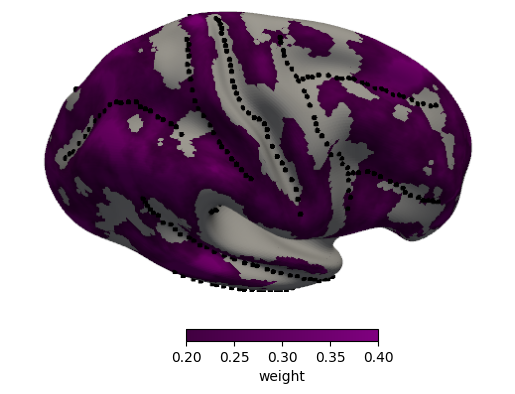

In [19]:
gifti = nb.load(os.path.join(gl.baseDir, 'smp2', gl.surfDir, f'searchlight.component_model.glm{glm}.exec.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)#[:, 2]

vmin, thresh, vmax = 0, .2, .4

data = data[:, 2] 

sulc = nt.get_gifti_data_matrix(nb.load(os.path.join('atlases', 'fs_LR.32k.LR.sulc.dscalar.gii')))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

cmap = LinearSegmentedColormap.from_list("surprise", ["black", "purple"])

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, data, H, cmap=cmap, vmin=vmin, vmax=vmax,  thresh=thresh)

# plot_surf colours the surface with clim=[vmin, vmax], i.e. cmap((v-vmin)/(vmax-vmin)),
# and hides voxels below thresh. So the dimmest colour actually shown is at v=thresh ->
# cmap((thresh-vmin)/(vmax-vmin)), NOT black. Truncate the colorbar's colormap to that
# same [thresh, vmax] segment so the low end of the bar matches the lowest colour in the figure.
frac = (thresh - vmin) / (vmax - vmin)
cmap_cbar = LinearSegmentedColormap.from_list("surprise_cbar", cmap(np.linspace(frac, 1.0, 256)))
sm = ScalarMappable(norm=Normalize(vmin=thresh, vmax=vmax), cmap=cmap_cbar)
cax = fig.add_axes([0.4, 0.1, 0.3, 0.025])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('weight')

fig.savefig(os.path.join('figures', f'surface.weight.exec.surprise.{H}.pdf'))

plt.show()